In [9]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize as sc
import datetime
import astropy
from astropy.time import Time
import astropy.units as u
from astropy import constants as const
from ipywidgets import interact
from ipywidgets import interact
import ipywidgets as widgets
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings

In [10]:

%%HTML
<style>
    body {
        --vscode-font-family: "Rockwell"
    }
</style>


In [11]:
warnings.filterwarnings('ignore')

In [12]:
def planck_spectrum(l, T):
    I = ((2*const.h*(const.c**2))/(l**5))*(1/(np.exp((const.h * const.c)/(l*const.k_B*T)) - 1))
    return I

Text(0.5, 1.0, 'Wet van Planck')

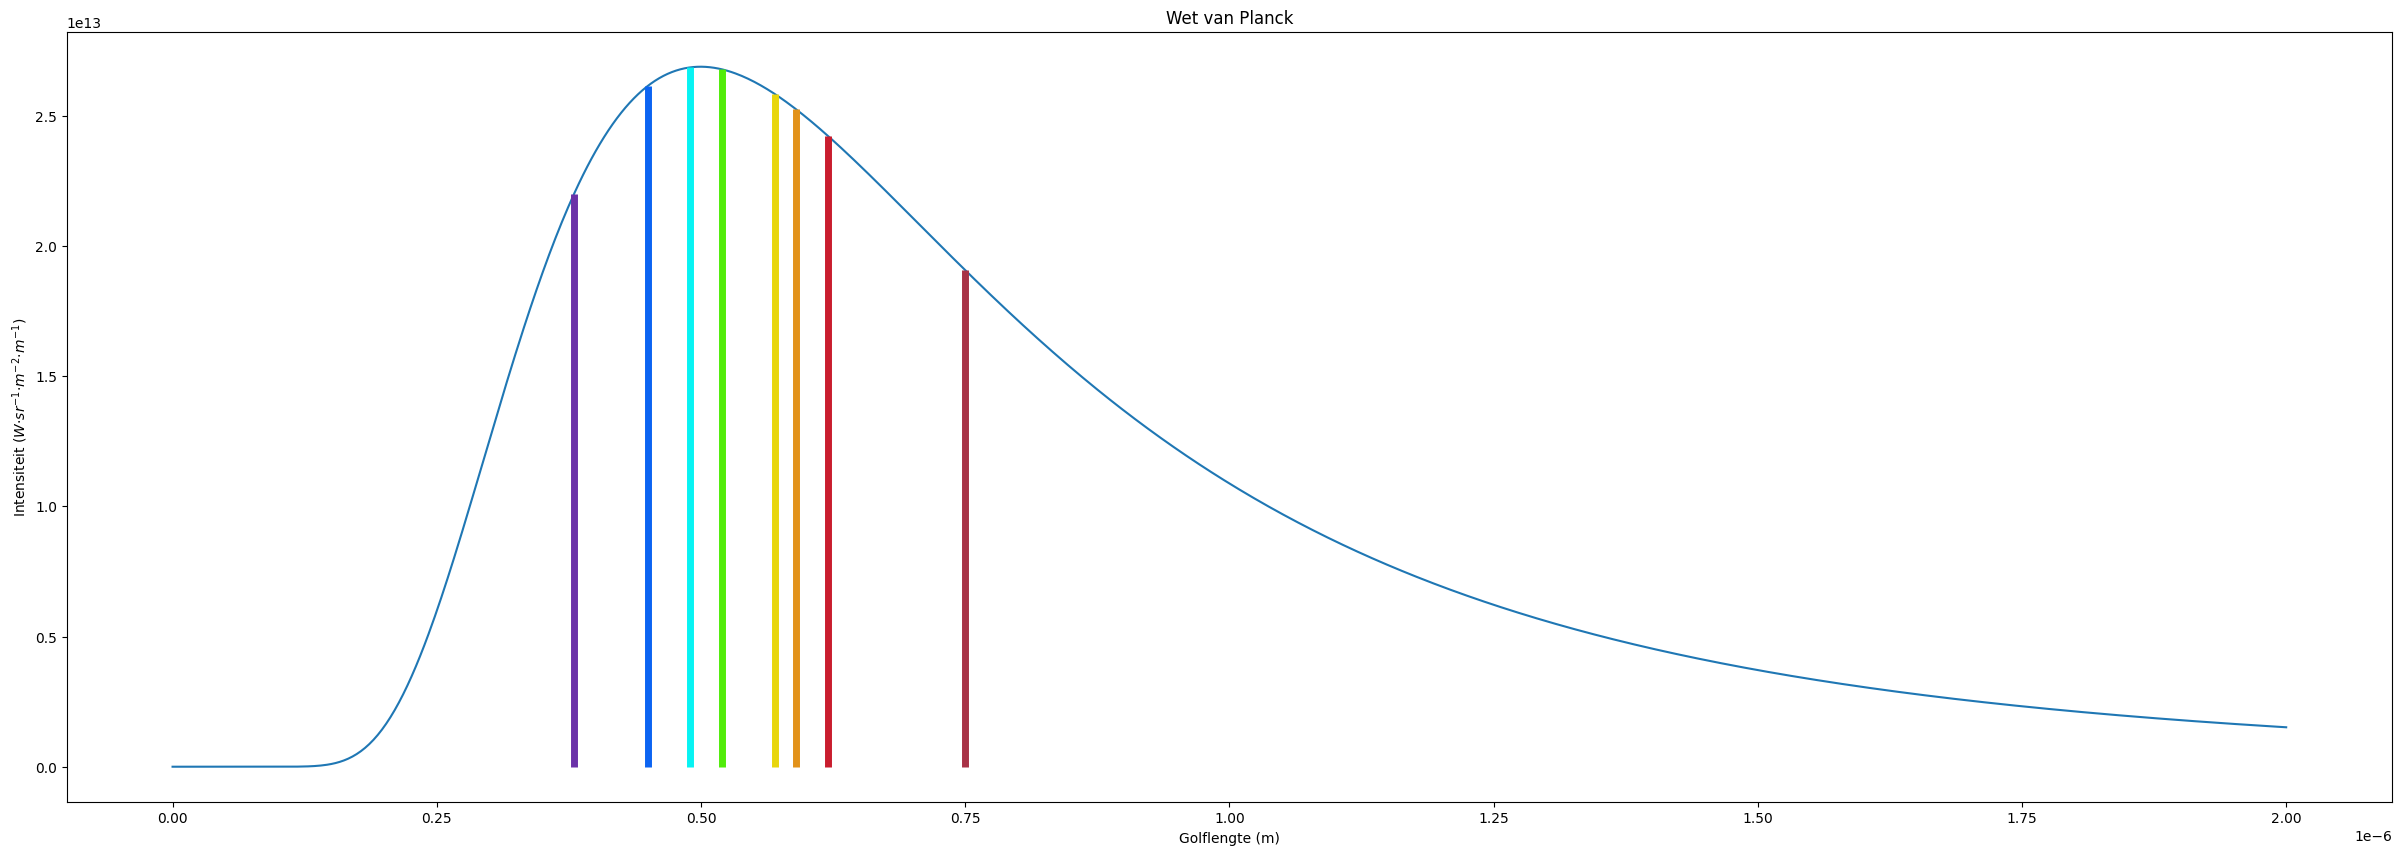

In [13]:
sun_temp = 5800 * u.K

wavelengths = np.linspace(0.000001 ,2, 1000)*10**(-6) * u.m

I_sun = planck_spectrum(wavelengths, sun_temp) 
plt.figure(figsize=(30,10))
plt.plot(wavelengths, I_sun)
optical = np.array([380,450,490,520, 570,590,620,750]) * 10**(-9) * u.m

I_optical = planck_spectrum(optical, sun_temp)
colors = ["#6b32a8", "#0c64f2","#07f3f3","#51ec0a","#e8d60c","#e2921a","#c91d2e","#a83246"]
plt.vlines(optical, np.zeros(len(optical)), I_optical, colors, linewidth=5)
plt.xlabel("Golflengte (m)")
plt.ylabel(r"Intensiteit $(W·sr^{-1}·m^{-2}·m^{-1})$")
plt.title("Wet van Planck")

In [14]:
max_val = 0
def interactive_plot(Temperatuur,Y_As):
    global max_val
    wavelengths = np.linspace(0.000001 ,2, 1000)*10**(-6) * u.m

    I_sun = planck_spectrum(wavelengths, Temperatuur*u.K) 
    # plt.figure(figsize=(30,10))
    plt.plot(wavelengths, I_sun)
    optical = np.array([380,450,490,520, 570,590,620,750]) * 10**(-9) * u.m

    I_optical = planck_spectrum(optical, Temperatuur*u.K)
    if Y_As:
        plt.ylim(0,max_val)
    else:
        max_val = np.max(I_sun.value)
    colors = ["#6b32a8", "#0c64f2","#07f3f3","#51ec0a","#e8d60c","#e2921a","#c91d2e","#a83246"]
    plt.vlines(optical, np.zeros(len(optical)), I_optical, colors, linewidth=2)
    plt.xlabel("Golflengte (m)")
    plt.ylabel(r"Intensiteit $(W·sr^{-1}·m^{-2}·m^{-1})$")

    plt.title("Wet van Planck")


interact(interactive_plot, Temperatuur=(20, 5800*2, 10), Y_As= False)

interactive(children=(IntSlider(value=5810, description='Temperatuur', max=11600, min=20, step=10), Checkbox(v…

<function __main__.interactive_plot(Temperatuur, Y_As)>

In [15]:
def wien(Temperatuur):
    l = const.b_wien/Temperatuur
    return l


# Wet van Wien 

$$ \lambda_{max} = \frac{k_w}{T}$$